<a href="https://colab.research.google.com/github/mmidkif/BME-450-Stroke-CT-Project/blob/main/BME_450_Stroke_CT_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Imports
from IPython.testing import test
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
import os
from google.colab import drive

#Load images into Colab
drive.mount('/content/drive', force_remount=True)
train_folder = '/content/drive/My Drive/Colab Notebooks/train_image/'
test_folder = '/content/drive/My Drive/Colab Notebooks/test_image/'

size = 256
transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor()
])

#Assign folders for training and test data
training_data = datasets.ImageFolder(root=train_folder, transform=transform)
trainloader = DataLoader(training_data, batch_size=10, shuffle=True, num_workers=2)
test_data = datasets.ImageFolder(root=test_folder, transform=transform)
testloader = DataLoader(test_data, batch_size=10, shuffle=True, num_workers=2)

classes = ['normal', 'stroke']

dataiter = iter(trainloader)
images, labels = next(dataiter)

#ResNet Architecture
class BasicBlock(nn.Module):
  expansion = 1

  def __init__(self, in_channels, out_channels, stride=1):
    super(BasicBlock, self).__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)

    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != self.expansion * out_channels:
      self.shortcut = nn.Sequential(
        nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
        nn.BatchNorm2d(self.expansion * out_channels))

  def forward(self, x):
    out = F.relu(self.bn1(self.conv1(x)))
    out = self.bn2(self.conv2(out))
    out += self.shortcut(x)
    out = F.relu(out)
    return out

class ResNet(nn.Module):
  def __init__(self, block, num_blocks, num_classes=2):
    super(ResNet, self).__init__()
    self.in_channels = 64

    # Initial convolutional layer and pooling
    self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
    self.bn1 = nn.BatchNorm2d(64)
    self.relu = nn.ReLU(inplace=True)
    self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

    # ResNet layers
    self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
    self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
    self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
    self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

    # Final pooling and fully connected layer
    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(512 * block.expansion, num_classes)

  def _make_layer(self, block, out_channels, num_blocks, stride):
      strides = [stride] + [1] * (num_blocks - 1)
      layers = []
      for stride in strides:
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels * block.expansion
      return nn.Sequential(*layers)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)

    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.fc(x)
    return x


#Device configuration
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

#Instantiate ResNet18
net = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=len(classes))
net.to(device)
# test sizes
net(images.to(device))

#Set optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())

#Run epochs
for epoch in range(2):  # loop over the dataset multiple times
  running_loss = 0.0
  correct_train = 0
  total_train = 0
  for i, data in enumerate(trainloader, 0):
    # get the inputs; data is a list of [inputs, labels]
    inputs, labels = data
    inputs, labels = inputs.to(device), labels.to(device) # Move data to GPU

    # zero the parameter gradients
    optimizer.zero_grad()
    # forward + backward + optimize
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    # calculate training accuracy
    _, predicted = torch.max(outputs.data, 1)
    total_train += labels.size(0)
    correct_train += (predicted == labels).sum().item()

    # print statistics
    running_loss += loss.item()
    if i % 200 == 199:    # print every 200 batches
      print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 200:.3f}, accuracy: {100 * correct_train / total_train:.2f}%')
      running_loss = 0.0
      correct_train = 0
      total_train = 0

print('Finished Training')

Mounted at /content/drive
Using device: cpu
[1,   200] loss: 0.616, accuracy: 68.45%
[1,   400] loss: 0.584, accuracy: 70.55%
[1,   600] loss: 0.587, accuracy: 70.25%
[2,   200] loss: 0.558, accuracy: 72.95%
[2,   400] loss: 0.538, accuracy: 72.80%
[2,   600] loss: 0.518, accuracy: 74.10%
Finished Training


In [ ]:
#Determine test accuracy
correct = 0
total = 0

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device) # Move data to GPU
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the test images: {100 * correct // total} %')

Accuracy of the network on the test images: 76 %


In [ ]:
#Determine test accuracy for each category
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device) # Move data to GPU
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: normal is 84.0 %
Accuracy for class: stroke is 55.1 %


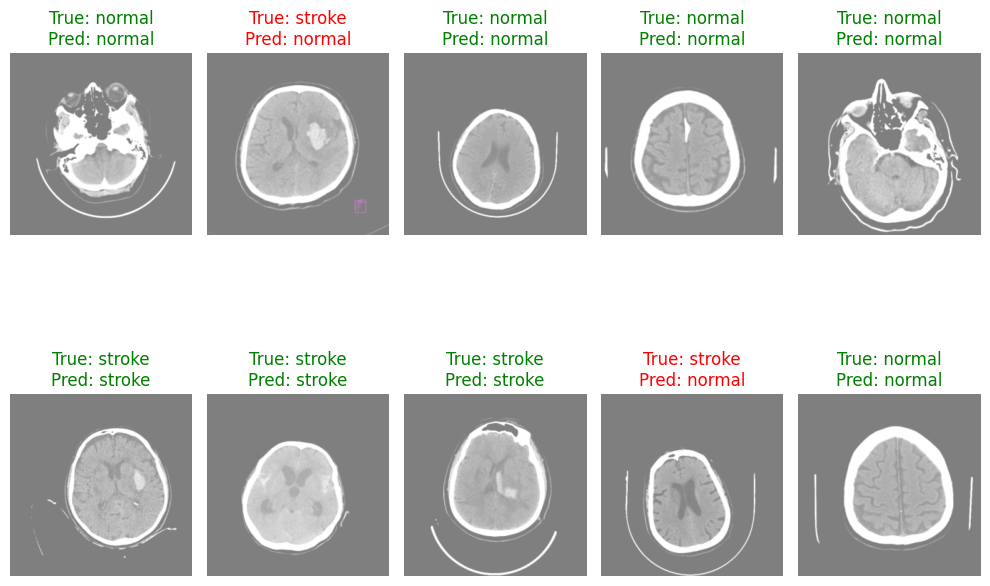

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#Get test images
dataiter = iter(testloader)
images, labels = next(dataiter)

#Move images to device
images = images.to(device)
labels = labels.to(device)

#Make predictions
outputs = net(images)
_, predicted = torch.max(outputs, 1)

#Function to unnormalize and display image
def imshow(img, ax):
    npimg = img.cpu().numpy() / 2 + 0.5
    ax.imshow(np.transpose(npimg, (1, 2, 0)))

#Plot images with labels and predictions
fig, axes = plt.subplots(figsize=(10, 8), nrows=2, ncols=5)
axes = axes.flatten()

for i in range(len(images)):
    if i >= 10: # Display up to 10 images
        break
    ax = axes[i]
    imshow(images[i], ax)
    ax.set_title(f"True: {classes[labels[i]]}\nPred: {classes[predicted[i]]}", color=('green' if predicted[i] == labels[i] else 'red'))
    ax.axis('off')

plt.tight_layout()
plt.show()